# Modular TD320 form OCR

This notebook is intentionally small. The reusable implementation lives in `config.py`, `preprocessing.py`, `model.py`, `utils.py`, `metrics.py`, and `main.py`. Run the cells in order.

## 1. Install dependencies once

Uncomment the command if the active `ocr` environment does not already contain the required packages. Restart the kernel after installation.

In [1]:
# %pip install -r requirements.txt

## 2. Select an accuracy profile

`balanced` is the recommended starting point. Use `simple` for a quick baseline, `accurate` for Qwen3-VL-4B, or `maximum` for the 8B model on a high-memory GPU. Individual values remain editable after the profile is created.

In [2]:
from pathlib import Path

from config import build_config

config = build_config(profile="accurate", root=Path("."))

# Optional adjustments:
# config.model.model_id = "Qwen/Qwen3-VL-4B-Instruct"
# config.paths.model_cache = Path("/your/large-storage/huggingface")
# config.preprocessing.clahe_clip_limit = 2.5
# config.preprocessing.views = ("original", "clahe", "otsu")

config.make_directories()
print("Profile:", config.profile)
print("Model:", config.model.model_id)
print("Views:", config.preprocessing.views)

Profile: accurate
Model: Qwen/Qwen3-VL-4B-Instruct
Views: ('original', 'clahe', 'otsu', 'adaptive')


## 3. Verify the GPU node

The node must have a visible CUDA GPU before model loading. This cell does not allocate model memory.

In [3]:
import socket

import torch

print("Node:", socket.gethostname())
print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f"Free/total VRAM: {free / 1024**3:.2f}/{total / 1024**3:.2f} GB")

Node: ecenod231
PyTorch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: NVIDIA A800 80GB PCIe
Free/total VRAM: 70.45/79.15 GB


## 4. Discover and preprocess `Chan`

This stage aligns and deskews the page, creates fixed field crops, and saves independent original/CLAHE/binary views. It can be checked without loading the VLM.

Original: figs/Chan.png
Preprocessed folder: preprocessed/Chan
Diagnostics: {'original_size': [1055, 1491], 'profile': 'accurate', 'views': ['original', 'clahe', 'otsu', 'adaptive'], 'template_alignment': {'aligned': True, 'matches': 386, 'inliers': 224}, 'deskew_angle_degrees': 0.0536, 'regions': {'identity': {'task': 'identity', 'box': (0.025, 0.17, 0.975, 0.305)}, 'residential': {'task': 'residential', 'box': (0.025, 0.275, 0.985, 0.545)}, 'correspondence': {'task': 'correspondence', 'box': (0.025, 0.495, 0.985, 0.725)}, 'declaration': {'task': 'declaration', 'box': (0.025, 0.685, 0.985, 0.985)}}}


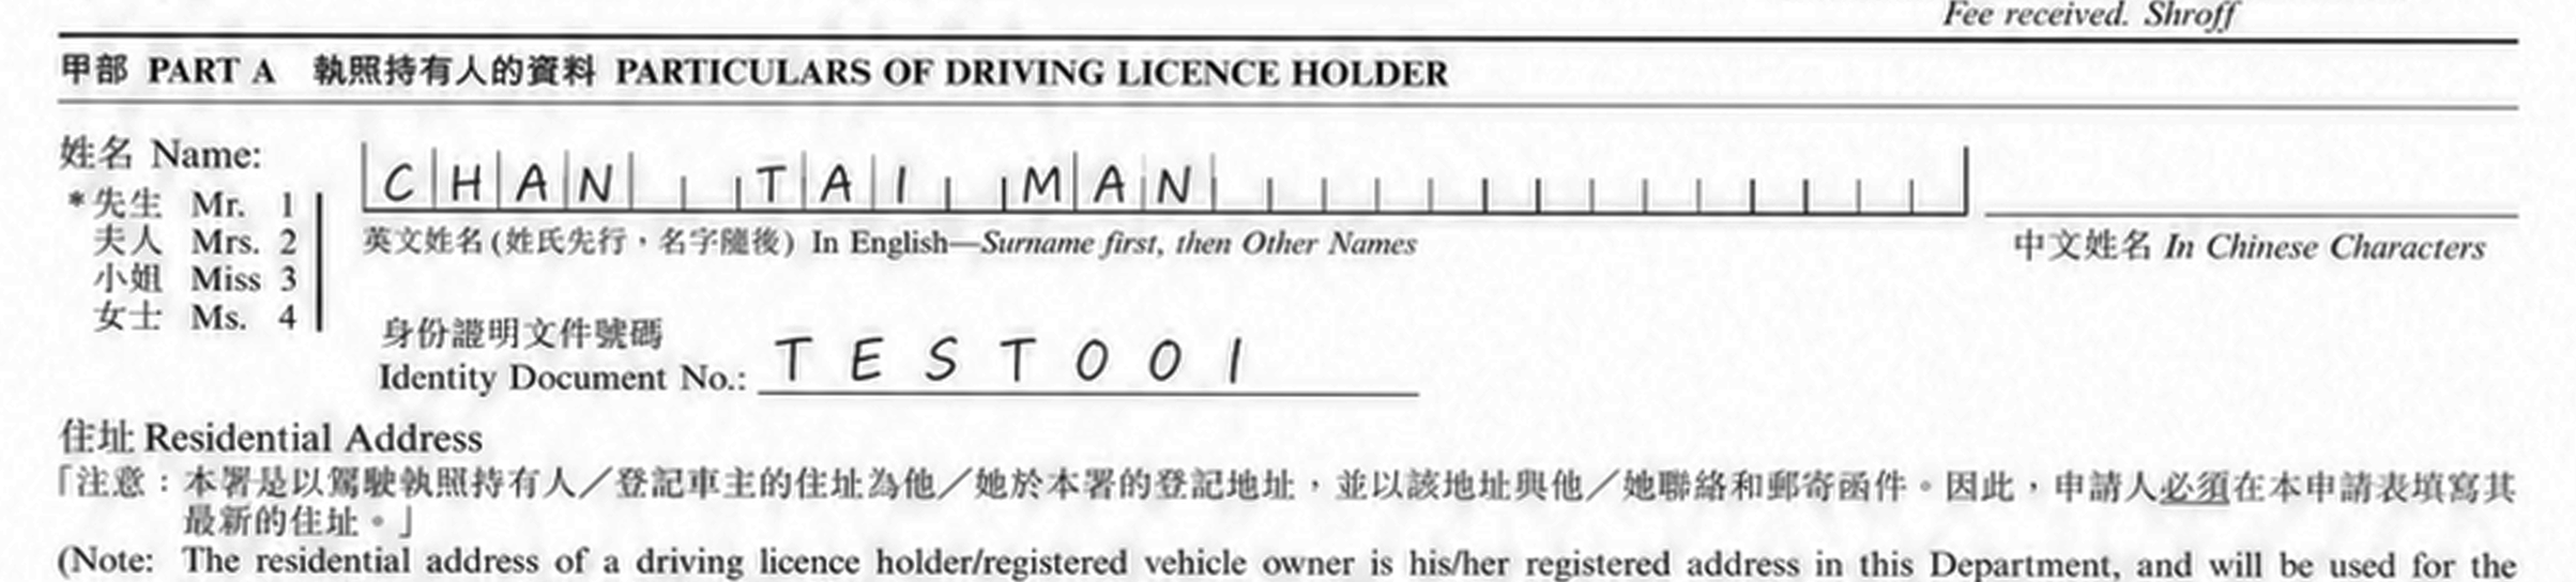

In [4]:
from IPython.display import display
from main import FormOCRPipeline, select_images
from PIL import Image

chan_path = select_images(config, config.example_name)[0]
pipeline = FormOCRPipeline(config)
preprocessed = pipeline.preprocess(chan_path)

print("Original:", preprocessed.original_path)
print("Preprocessed folder:", preprocessed.aligned_path.parent)
print("Diagnostics:", preprocessed.metadata)

preview_path = preprocessed.crops["identity"].get(
    "clahe", preprocessed.crops["identity"]["original"]
)
display(Image.open(preview_path))

## 5. Load the model and process `Chan`

Each preprocessing view is evaluated independently. Values are accepted by agreement; conflicts are written to the audit instead of being guessed.

In [5]:
pipeline.load_model()
chan_result = pipeline.process_image(chan_path)
chan_result

/home/hnksm/.conda/envs/ocr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|████████████████████████████████████████████████████████████████████████████| 713/713 [00:23<00:00, 30.31it/s]


{'image': 'Chan.png',
 'status': 'needs_review',
 'output': 'output/Chan',
 'elapsed_seconds': 122.91}

## 6. Review the audit before the batch

`passed_automated_checks` is not a guarantee of character-level correctness. Inspect disagreement candidates and compare important fields with their saved crops.

In [6]:
import json

audit_path = config.paths.output / chan_path.stem / f"{chan_path.stem}_audit.json"
audit = json.loads(audit_path.read_text(encoding="utf-8"))
print(json.dumps(audit, ensure_ascii=False, indent=2))

{
  "status": "needs_review",
  "review_items": [
    {
      "field": "residential.flat",
      "issue": "View disagreement or insufficient agreement",
      "required_votes": 2,
      "candidates": [
        {
          "value": "12 B",
          "state": "filled"
        },
        {
          "value": "12B",
          "state": "filled"
        },
        {
          "value": "12B",
          "state": "filled"
        },
        {
          "value": "",
          "state": "blank"
        }
      ]
    },
    {
      "field": "residential.floor",
      "issue": "View disagreement or insufficient agreement",
      "required_votes": 2,
      "candidates": [
        {
          "value": "12",
          "state": "filled"
        },
        {
          "value": "12",
          "state": "filled"
        },
        {
          "value": "12",
          "state": "filled"
        },
        {
          "value": "",
          "state": "blank"
        }
      ]
    },
    {
      "field": "resid

## 7. Process the remaining images

After checking `Chan`, process the rest without sending it to the model again. An individual failure is recorded without discarding successful results.

In [7]:
all_images = select_images(config)
remaining = [path for path in all_images if path != chan_path]
summary = [chan_result]
if remaining:
    summary.extend(pipeline.run_batch(remaining))

from utils import write_json

write_json(config.paths.output / "batch_summary.json", summary)
summary

[1/4] Hassan.png
  needs_review
[2/4] Lee.png
  passed_automated_checks
[3/4] td320_form_borders_only.png
  passed_automated_checks
[4/4] Wong.png
  needs_review


[{'image': 'Chan.png',
  'status': 'needs_review',
  'output': 'output/Chan',
  'elapsed_seconds': 122.91},
 {'image': 'Hassan.png',
  'status': 'needs_review',
  'output': 'output/Hassan',
  'elapsed_seconds': 126.39},
 {'image': 'Lee.png',
  'status': 'passed_automated_checks',
  'output': 'output/Lee',
  'elapsed_seconds': 124.16},
 {'image': 'td320_form_borders_only.png',
  'status': 'passed_automated_checks',
  'output': 'output/td320_form_borders_only',
  'elapsed_seconds': 103.85},
 {'image': 'Wong.png',
  'status': 'needs_review',
  'output': 'output/Wong',
  'elapsed_seconds': 126.96}]

## 8. Evaluate against checked ground truth

Create `ground_truth/Chan.json` with the same English keys, then calculate exact match, character error rate, edit similarity, and nonblank precision/recall/F1.

In [9]:
from metrics import evaluate_files

prediction_path = config.paths.output / "Chan" / "Chan_English.json"
reference_path = Path("ground_truth/Chan.json")

if reference_path.exists():
    report = evaluate_files(prediction_path, reference_path)
    print(json.dumps(report, ensure_ascii=False, indent=2))
else:
    print("Add ground_truth/Chan.json to run evaluation.")

{
  "field_count": 21,
  "field_exact_match_accuracy": 1.0,
  "character_error_rate": 0.0,
  "mean_field_similarity": 1.0,
  "nonblank_precision": 1.0,
  "nonblank_recall": 1.0,
  "nonblank_f1": 1.0,
  "per_field": {
    "agent_identity_document_number": {
      "exact": true,
      "edit_distance": 0,
      "similarity": 1.0,
      "prediction": "",
      "reference": ""
    },
    "agent_name": {
      "exact": true,
      "edit_distance": 0,
      "similarity": 1.0,
      "prediction": "",
      "reference": ""
    },
    "correspondence_address.block": {
      "exact": true,
      "edit_distance": 0,
      "similarity": 1.0,
      "prediction": "",
      "reference": ""
    },
    "correspondence_address.building": {
      "exact": true,
      "edit_distance": 0,
      "similarity": 1.0,
      "prediction": "",
      "reference": ""
    },
    "correspondence_address.district": {
      "exact": true,
      "edit_distance": 0,
      "similarity": 1.0,
      "prediction": "",
      "